# SOD1 Docking: Pareto Optimisation & Molecule Ranking

This notebook ranks `MOL-*` candidates from `Project_Workbook_SOD1_Docking_20_August_2026.xlsx` in two stages:

**Stage 1: Docking / pose objectives (Pareto front)**
- Average ChemPLP comparison: higher is better
- Standard Deviation (docking): lower is better
- Ligand Efficiency: higher is better
- Pose Consistency (SD across crystal structures): lower is better
- Weighted Score (%): higher is better, **hard filter: must be > 70**

**Stage 2: ADMET, physicochemical & chirality tie-break**
Used to rank molecules that tie (or sit close together) on Stage 1, using ADMET risk/benefit, QED, Lipinski violations and whether chirality is defined.

Output: `pareto_ranked_molecules.csv` with a final `Final_Rank` column and `top10_per_template`.


In [1]:
# 1. Imports Libraries
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)


## 2. Load workbook

Update `EXCEL_PATH` to direct it to the excel worksheet titled ` Project_Workbook_SOD1_Docking_20_August_2026 `.

In [2]:
# 2. Load workbook
EXCEL_PATH = Path(r"C:\Users\anjal\OneDrive - The University of Liverpool\Project_CHEM526\MS Excel Book1\Project_Workbook_SOD1_Docking_20_AUGUST_2026.xlsx")

if not EXCEL_PATH.exists():
    raise FileNotFoundError(f"Workbook not found: {EXCEL_PATH}")

xls = pd.ExcelFile(EXCEL_PATH, engine="openpyxl")
print("Sheets found:", xls.sheet_names)


Sheets found: ['Docking Score, SD and Ligand Ef', 'Pose Consistency and Docking Re', 'Physicochemical and Chirality P', 'ADMET Properties', 'Binding Site Interaction Analys']


## 3. Helper to clean a sheet

Every sheet in this workbook has thousands of blank trailing columns (`Unnamed: N`, `ColumnN`)
left over from Excel formatting. This helper strips those out so we only keep real data columns.

* This is a crutial step because all the sheet has 16,000+ mostly-empty columns per sheet, which is slow and pollutes anything downstream.
Hence, ensures loading cleaan data

* Workbook has fragment-stage molecules (FRAG-001) because they were essential initailly for data collection and calcualtions in primary stage but, for this optimisation they need to be filtered out along with template markers, and blank spacer rows in with actual candidate molecules (MOL-001RR, etc.). The code keeps only rows whose Molecule ID starts with "MOL".

In [3]:
# 3. Sheet-cleaning helper
def load_sheet(xls, name):
    """Read a sheet and drop all-empty / auto-generated placeholder columns."""
    df = pd.read_excel(xls, sheet_name=name, engine="openpyxl")
    df = df.dropna(axis=1, how="all")
    df = df.loc[:, ~df.columns.astype(str).str.contains(r"^Unnamed")]
    df = df.loc[:, ~df.columns.astype(str).str.match(r"^Column\d*$")]
    return df

def mol_only(df):
    """Keep only rows whose Molecule ID starts with 'MOL' (drops fragments/templates/blank rows)."""
    return df[df["Molecule ID"].astype(str).str.startswith("MOL")].copy()


## 4. Load and reshape each of the 5 sheets

- **Sheet 1** (docking score, SD, LE): one row per molecule, used as-is.
- **Sheet 2** (pose consistency): two rows per molecule (one per crystal structure: 2WZ6, 4A7T).
  Hence average the Standard Deviation and Average ChemPLP across both to get one "pose consistency" value per molecule and naming new column as pose_consistency_sd, and pose_avg_chemplp.
- **Sheet 3** (physicochemical + chirality): one row per molecule, used as-is.
- **Sheet 4** (ADMET): one row per molecule, used as-is.
- **Sheet 5** (binding site / weighted score): two rows per molecule (per crystal structure). We average
  `Weighted Score (%)` across both structures to get one score per molecule.


In [4]:
# 4a. Sheet 1: Docking Score, SD, Ligand Efficiency 
d1 = load_sheet(xls, "Docking Score, SD and Ligand Ef")
d1 = mol_only(d1)
d1 = d1.rename(columns={
    "Average ChemPLP comparison": "avg_chemplp_comparison",
    "Standard Deviation": "docking_std_dev",
    "Ligand\xa0Efficiency= Average ChemPLP fitness score / heavy atom count": "ligand_efficiency",
    "Chirality": "chirality_code",
    "Molecule type": "template",
})
# NOTE: "template" values have inconsistent trailing whitespace in the source
# sheet (e.g. "Template 1 " vs "Template 1") — strip it so grouping works correctly.
d1["template"] = d1["template"].astype(str).str.strip()

d1 = d1[["Molecule ID", "chirality_code", "template",
         "avg_chemplp_comparison", "docking_std_dev", "ligand_efficiency"]]
d1.head()


,Molecule ID,chirality_code,template,avg_chemplp_comparison,docking_std_dev,ligand_efficiency
8,MOL-001RR,RR,Template 2,14.85,16.475588,2.359677
9,MOL-001RS,RS,Template 2,10.4,21.496046,2.216129
10,MOL-001SR,SR,Template 2,9.0,19.233304,2.170968
11,MOL-001SS,SS,Template 2,6.6,20.647518,2.093548
12,MOL-002RR,RR,Template 2,10.1,15.556349,2.1375


In [5]:
# 4b. Sheet 2: Pose Consistency (aggregate 2 crystal structures per molecule)
d2 = load_sheet(xls, "Pose Consistency and Docking Re")
d2 = mol_only(d2)
d2_agg = d2.groupby("Molecule ID").agg(
    pose_consistency_sd=("Standard Deviation", "mean"),
    pose_avg_chemplp=("Average ChemPLP Score", "mean"),
).reset_index()
d2_agg.head()


,Molecule ID,pose_consistency_sd,pose_avg_chemplp
0,MOL-001RR,5.012903,63.0675
1,MOL-001RS,6.574175,59.6495
2,MOL-001SR,3.498853,60.6717
3,MOL-001SS,2.753597,62.9835
4,MOL-002RR,4.974391,60.7395


In [6]:
# 4c. Sheet 3: Physicochemical + Chirality
d3 = load_sheet(xls, "Physicochemical and Chirality P")
d3 = mol_only(d3)
d3.head()


,Molecule ID,SMILES,Sterocenteres,Chirality Defined,Molecular Weight (MW),TPSA,HBA,HBD,LogP,LogD,LogS,Rotational Bonds,Rings,Fsp3,QED,Lipinski
0,MOL-001RR,COc1nc(N2CCN(C)CC(CC(O)c3ccc(O)c(O)c3)C2)c2ccc...,2,Yes,424.21,102.18,8,3,2.255,2.397,-3.384,5,4,0.391,0.537,0
1,MOL-001RS,COc1nc(N2CCN(C)C[C@@H](C[C@H](O)c3ccc(O)c(O)c3...,2,Yes,424.21,102.18,8,3,2.430,2.460,-3.600,5,4,0.391,0.537,0
2,MOL-001SR,COc1nc(N2CCN(C)C[C@H](C[C@@H](O)c3ccc(O)c(O)c3...,2,Yes,424.21,102.18,8,3,2.420,2.480,-3.987,5,4,0.391,0.537,0
3,MOL-001SS,COc1nc(N2CCN(C)C[C@H](C[C@H](O)c3ccc(O)c(O)c3)...,2,Yes,424.21,102.18,8,3,2.619,2.652,-4.102,5,4,0.391,0.537,0
4,MOL-002RR,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@H](C[C@@H](O...,2,Yes,437.21,136.04,9,5,1.480,1.740,-3.079,5,4,0.348,0.442,0


In [7]:
# 4d. Sheet 4: ADMET Properties 
d4 = load_sheet(xls, "ADMET Properties")
d4 = mol_only(d4)
d4.head()


,Molecule ID,HIA,Caco-2,MDCK,PAMPA,BBB,PPB,P-gp inhibitor,P-gp Substrate,CYP3A4 substarte,CYP2C19 substarte,CYP2C9 substrate,Half-Life (10.5),h ERG,DILI,Ames,Carcinogenicity,Clearance (cl-plasma)
0,MOL-001RR,0.9954,-5.186,-4.890,0.7500,0.9640,0.884,4.800000e-03,-0.000006,0.7800,0.1030,0.084000,10.71,0.8840,0.7050,0.0320,0.550,0.9740
1,MOL-001RS,0.9600,-5.150,-4.820,0.5500,0.9460,0.780,0.000000e+00,0.085,0.9466,0.0328,0.026000,11.30,0.7844,0.5352,0.0520,0.653,0.8303
2,MOL-001SR,0.9400,-5.072,-4.840,0.7170,0.3677,0.701,0.000000e+00,0.0183,0.9500,0.1030,0.068000,10.42,0.7016,0.5900,0.0473,0.580,0.7106
3,MOL-001SS,0.9500,-5.166,-4.877,0.6577,0.8200,0.808,0.000000e+00,0.0098,0.9310,0.1100,0.001100,11.34,0.8088,0.7300,0.0886,0.780,0.6511
4,MOL-002RR,0.8020,-5.760,-5.099,0.5500,0.8020,0.810,3.320000e-07,0.09006,0.9599,0.0339,0.000303,9.42,0.8190,0.1420,0.0630,0.630,0.5500


In [8]:
# 4e. Sheet 5: Binding Site Interaction Analysis
import pandas as pd

EXCEL_PATH = r"C:\Users\anjal\OneDrive - The University of Liverpool\Project_CHEM526\MS Excel Book1\Project_Workbook_SOD1_Docking_20_AUGUST_2026.xlsx"
SHEET_NAME = "Binding Site Interaction Analys"

# Read only columns A to K. This sheet's real data is just 11 columns wide,
d5 = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME, engine="openpyxl", usecols="A:K")
print("Loaded sheet, shape:", d5.shape)

# Drop any fully empty columns left over from the read
d5 = d5.dropna(axis=1, how="all")

# Keep only real candidate molecules (drops fragments, templates, blank rows)
d5 = d5[d5["Molecule ID"].astype(str).str.startswith("MOL")].copy()
print("After filtering to MOL rows:", d5.shape)

# This sheet has 2 rows per molecule (one per crystal structure: 2WZ6, 4A7T)
# Average Weighted Score (%) across both to get one value per molecule
d5_agg = d5.groupby("Molecule ID").agg(
    weighted_score_pct=("Weighted Score (%)", "mean")
).reset_index()

print("Aggregated shape:", d5_agg.shape)
d5_agg.head(10)

Loaded sheet, shape: (287, 11)
After filtering to MOL rows: (287, 11)
Aggregated shape: (144, 2)


,Molecule ID,weighted_score_pct
0,MOL-001RR,61.111111
1,MOL-001RS,83.333333
2,MOL-001SR,66.666667
3,MOL-001SS,83.333333
4,MOL-002RR,44.444444
5,MOL-002RS,66.666667
6,MOL-002SR,61.111111
7,MOL-002SS,88.888889
8,MOL-003RR,61.111111
9,MOL-003RS,77.777778


## 5. Merge everything into one master table (keyed on Molecule ID)
All five (now one-row-per-molecule) tables get merged together using Molecule ID .This is just a standard left-join chain, conceptually the same as VLOOKUP across sheets, but doing all of them in one pass.

* The result is a single table where each row is a molecule and each column is a property pulled from wherever it lives in the original workbook. 

**It is important to flag that during the process of merging there could be some missing rows or misspelled data if the merge is not consistent. So, adding this comment to flag such occurance is essential to ensure data quality is maintained.** 


In [9]:
# 5. Merge all sheets on Molecule ID
master = (
    d1.merge(d2_agg, on="Molecule ID", how="left")
      .merge(d3,     on="Molecule ID", how="left")
      .merge(d4,     on="Molecule ID", how="left")
      .merge(d5_agg, on="Molecule ID", how="left")
)

print("Master table shape:", master.shape)
missing = master.isna().sum()
missing = missing[missing > 0]
if len(missing):
    print("\nColumns with missing values after merge (check Molecule ID spelling in source sheets):")
    print(missing)

master.head()


Master table shape: (144, 41)

Columns with missing values after merge (check Molecule ID spelling in source sheets):
pose_consistency_sd      2
pose_avg_chemplp         2
SMILES                   2
Sterocenteres            2
Chirality Defined        2
Molecular Weight (MW)    2
TPSA                     2
HBA                      2
HBD                      2
LogP                     2
LogD                     2
LogS                     2
Rotational Bonds         2
Rings                    2
Fsp3                     2
QED                      2
Lipinski                 2
HIA                      5
Caco-2                   5
MDCK                     5
PAMPA                    5
BBB                      5
PPB                      5
P-gp inhibitor           5
P-gp Substrate           5
CYP3A4 substarte         5
CYP2C19 substarte        5
CYP2C9 substrate         5
Half-Life (10.5)         5
h ERG                    5
DILI                     5
Ames                     5
Carcinogenicity   

,Molecule ID,chirality_code,template,avg_chemplp_comparison,docking_std_dev,ligand_efficiency,pose_consistency_sd,pose_avg_chemplp,SMILES,Sterocenteres,Chirality Defined,Molecular Weight (MW),TPSA,HBA,HBD,LogP,LogD,LogS,Rotational Bonds,Rings,Fsp3,QED,Lipinski,HIA,Caco-2,MDCK,PAMPA,BBB,PPB,P-gp inhibitor,P-gp Substrate,CYP3A4 substarte,CYP2C19 substarte,CYP2C9 substrate,Half-Life (10.5),h ERG,DILI,Ames,Carcinogenicity,Clearance (cl-plasma),weighted_score_pct
0,MOL-001RR,RR,Template 2,14.85,16.475588,2.359677,5.012903,63.0675,COc1nc(N2CCN(C)CC(CC(O)c3ccc(O)c(O)c3)C2)c2ccc...,2.0,Yes,424.21,102.18,8.0,3.0,2.255,2.397,-3.384,5.0,4.0,0.391,0.537,0.0,0.9954,-5.186,-4.890,0.7500,0.9640,0.884,4.800000e-03,-0.000006,0.7800,0.1030,0.084000,10.71,0.8840,0.7050,0.0320,0.550,0.9740,61.111111
1,MOL-001RS,RS,Template 2,10.4,21.496046,2.216129,6.574175,59.6495,COc1nc(N2CCN(C)C[C@@H](C[C@H](O)c3ccc(O)c(O)c3...,2.0,Yes,424.21,102.18,8.0,3.0,2.430,2.460,-3.600,5.0,4.0,0.391,0.537,0.0,0.9600,-5.150,-4.820,0.5500,0.9460,0.780,0.000000e+00,0.085,0.9466,0.0328,0.026000,11.30,0.7844,0.5352,0.0520,0.653,0.8303,83.333333
2,MOL-001SR,SR,Template 2,9.0,19.233304,2.170968,3.498853,60.6717,COc1nc(N2CCN(C)C[C@H](C[C@@H](O)c3ccc(O)c(O)c3...,2.0,Yes,424.21,102.18,8.0,3.0,2.420,2.480,-3.987,5.0,4.0,0.391,0.537,0.0,0.9400,-5.072,-4.840,0.7170,0.3677,0.701,0.000000e+00,0.0183,0.9500,0.1030,0.068000,10.42,0.7016,0.5900,0.0473,0.580,0.7106,66.666667
3,MOL-001SS,SS,Template 2,6.6,20.647518,2.093548,2.753597,62.9835,COc1nc(N2CCN(C)C[C@H](C[C@H](O)c3ccc(O)c(O)c3)...,2.0,Yes,424.21,102.18,8.0,3.0,2.619,2.652,-4.102,5.0,4.0,0.391,0.537,0.0,0.9500,-5.166,-4.877,0.6577,0.8200,0.808,0.000000e+00,0.0098,0.9310,0.1100,0.001100,11.34,0.8088,0.7300,0.0886,0.780,0.6511,83.333333
4,MOL-002RR,RR,Template 2,10.1,15.556349,2.1375,4.974391,60.7395,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@H](C[C@@H](O...,2.0,Yes,437.21,136.04,9.0,5.0,1.480,1.740,-3.079,5.0,4.0,0.348,0.442,0.0,0.8020,-5.760,-5.099,0.5500,0.8020,0.810,3.320000e-07,0.09006,0.9599,0.0339,0.000303,9.42,0.8190,0.1420,0.0630,0.630,0.5500,44.444444


## 6. Stage 1: Pareto ranking on docking / pose objectives

Steps: 

6. a **Hard filter**: `Weighted Score (%)` must be **above 70**. 

* Because Average CemPLP score showed strong binding so docking hence hard filtering on weighted score that dermines if the molecule is actually binding to the binding site it was supposed to bind is important criteria for its filtering. Docking scores are considered for normalization along with other parameters because of no refernce ligand availibility. 
6. b  **Normalization** Remaining objectives are normalised 0–1 (direction-aware) and combined into a **Pareto front**
   using standard non-dominated sorting; a molecule that is not beaten on *every* objective by
   another molecule survives at a better (lower-numbered) front.

* Further elaboration the five remaining objectives were not on the same scale. This made them impossible to compare directly. 
For example, the Average ChemPLP comparison values ranged from about 5 to 20. The Standard Deviation values ranged from about 3 to 30. Ligand Efficiency values sat around 2. These numbers cannot be judged side by side as they are, because a difference of 1 point means something totally different for each metric.

* To fix this, I rescaled every objective so it sits between 0 and 1. I made sure that 1 always meant "the best possible value" for that objective, no matter what the original numbers looked like. This step is called min-max normalisation, and it is a standard technique used whenever you need to compare variables that are on different scales.

* The direction of "better" is not the same for every objective, so I had to handle this carefully. For objectives where a higher number is better, like ChemPLP comparison, Ligand Efficiency, and the Weighted Score, I set the highest value in my dataset to equal 1. For objectives where a lower number is actually better, like Standard Deviation and pose inconsistency, I flipped the scale around. This meant the lowest value in my dataset became 1, since a low standard deviation is what I actually wanted.

* By doing this, every single objective ends up using the same rule. A score of 1 always means the best possible outcome, and a score close to 0 always means the worst. This makes it possible to compare completely different types of measurements fairly, and it sets up the next step, where I check which molecules dominate others across all objectives at once.

6. c **Pareto Dominace** Within the same front, molecules are ordered by a composite (mean of normalised objectives) score.

* This step is the core step of the whole method. One molecule dominates another molecule if it is at least as good on every single objective, and strictly better on at least one of them. For example, Molecule A has a better ChemPLP comparison than Molecule B, better consistency than B, and better ligand efficiency than B, all at the same time. In this case, B is dominated. It is worse than A in every way that matters, so it is removed from the top tier straight away.

* But this does not always happen so cleanly. Sometimes Molecule A has a better ChemPLP comparison, while Molecule B has better ligand efficiency instead. Neither one beats the other on everything. This is a genuine trade off. When this happens, Pareto optimisation keeps both molecules. Hence flagging one better than other at this stage is not correct.

* Hence, using a method called non-dominated sorting. First, find every molecule that is not dominated by anyone else in the dataset. This group becomes Pareto Front 1, which is basically the best possible set of trade offs in the whole dataset. Then removing those molecules from consideration, and repeat the same process on what is left. This gives Front 2.  Then keep repeating this until every molecule in dataset has been placed into a front.

* This establishes the unbaised ranking that is intended for this project. Molecules in Front 1 are the true best candidates, with no compromises. Molecules in later fronts are progressively more compromised, since they are beaten by more molecules overall.

Additionally, within the same front I sort molecules using a simple composite score, which is just the average of their five normalised values. I only use this to decide the order I present molecules in in the notebook for ease of readability. 


In [10]:
# 6a. Hard filter: Weighted Score (%) > 70 
before = len(master)
m = master.dropna(subset=["weighted_score_pct"]).copy()
m = m[m["weighted_score_pct"] > 70].copy()
print(f"Weighted Score > 70 filter: {before} -> {len(m)} molecules remain")


Weighted Score > 70 filter: 144 -> 58 molecules remain


In [11]:
# 6b. Normalise objectives (direction-aware)
objectives = {
    "avg_chemplp_comparison": "max",   # higher ChemPLP comparison = stronger binding
    "docking_std_dev":        "min",   # lower SD = more reproducible docking score
    "ligand_efficiency":      "max",   # higher LE = better binding per heavy atom
    "pose_consistency_sd":    "min",   # lower pose SD = more reliable/consistent poses
    "weighted_score_pct":     "max",   # higher interaction fidelity
}

def normalize(series, direction):
    s = series.astype(float)
    rng = s.max() - s.min()
    if rng == 0:
        return pd.Series(1.0, index=s.index)
    n = (s - s.min()) / rng
    return n if direction == "max" else 1 - n

norm_cols = []
for col, direction in objectives.items():
    ncol = f"norm_{col}"
    m[ncol] = normalize(m[col], direction)
    norm_cols.append(ncol)


In [12]:
# 6c. Non-dominated (Pareto) sorting
def dominates(a, b):
    """True if solution `a` is at least as good as `b` on every objective, and strictly better on one."""
    return all(a[c] >= b[c] for c in norm_cols) and any(a[c] > b[c] for c in norm_cols)

def pareto_ranks(df):
    idx = df.index.to_list()
    dom_count = {i: 0 for i in idx}
    for i in idx:
        for j in idx:
            if i != j and dominates(df.loc[j], df.loc[i]):
                dom_count[i] += 1

    ranks, remaining, current_rank = {}, dict(dom_count), 1
    while remaining:
        front = [i for i, c in remaining.items() if c == 0] or list(remaining.keys())
        for i in front:
            ranks[i] = current_rank
        for i in front:
            del remaining[i]
        for i in remaining:
            beaten = sum(1 for f in front if dominates(df.loc[f], df.loc[i]))
            remaining[i] = max(0, remaining[i] - beaten)
        current_rank += 1
    return ranks

m["pareto_rank"] = m.index.map(pareto_ranks(m))
m["stage1_composite"] = m[norm_cols].mean(axis=1)

m[["Molecule ID", "pareto_rank", "stage1_composite"] + list(objectives.keys())] \
    .sort_values(["pareto_rank", "stage1_composite"], ascending=[True, False]) \
    .head(15)


,Molecule ID,pareto_rank,stage1_composite,avg_chemplp_comparison,docking_std_dev,ligand_efficiency,pose_consistency_sd,weighted_score_pct
13,MOL-004RS,1,0.794735,14.3,18.243355,2.42,5.251373,83.333333
138,MOL-047R,1,0.762467,13.015,18.151431,2.377167,6.623334,83.333333
71,MOL-024S,1,0.761429,15.5,18.80904,2.30625,5.668583,83.333333
55,MOL-019RS,1,0.751632,13,13.010765,2.228125,7.809308,83.333333
23,MOL-008S,1,0.736438,11.95,11.242998,2.341667,4.977027,77.777778
85,MOL-029RS,1,0.734738,5.55,8.131728,2.280357,5.917977,83.333333
126,MOL-043R,1,0.733516,9.565,18.575695,2.42375,7.936024,83.333333
124,MOL-042SR,1,0.726217,5.35,5.444722,2.194828,5.709133,83.333333
60,MOL-021RR,1,0.723517,13.85,14.778532,2.327419,4.061292,77.777778
125,MOL-042SS,1,0.704499,8.7,8.909545,2.310345,7.023845,77.777778


Once I had my Pareto ranked shortlist, I still needed a way to order molecules that landed on the same front. The Pareto step tells me which molecules represent genuine trade offs and which ones are dominated, but it does not tell me which molecule to prioritise first when several of them are equally valid. So I added a second scoring layer on top, just for this purpose.



## 7. Stage 2: ADMET, physicochemical & chirality tie-break

For molecules that land on the same Pareto front, we rank by a secondary composite score built from:
- **ADMET**: HIA, Caco-2, PAMPA, BBB (benefit: higher better) and hERG, DILI, Ames, Carcinogenicity, "P-gp inhibitor", "P-gp Substrate" , Clearance (risk: lower better) 
- **QED** (drug-likeness, higher better)
- **Lipinski violations** (fewer is better)
- **Chirality defined** (stereochemistry is fully specified)



In [13]:
# 7. ADMET + physicochemical + chirality composite
admet_beneficial = ["HIA", "Caco-2", "PAMPA", "BBB"]
admet_risk       = ["h ERG", "DILI", "Ames", "Carcinogenicity", "Clearance (cl-plasma)", "P-gp inhibitor", "P-gp Substrate"]

for col in admet_beneficial:
    m[f"n_{col}"] = normalize(m[col], "max")
for col in admet_risk:
    m[f"n_{col}"] = normalize(m[col], "min")

m["admet_score"] = m[[f"n_{c}" for c in admet_beneficial + admet_risk]].mean(axis=1)

m["qed_norm"]         = normalize(m["QED"], "max")
m["lipinski_norm"]    = normalize(m["Lipinski"], "min")
m["chirality_bonus"]  = (m["Chirality Defined"].astype(str).str.lower() == "yes").astype(float)

m["stage2_composite"] = (
    0.50 * m["admet_score"] +
    0.30 * m["qed_norm"] +
    0.15 * m["lipinski_norm"] +
    0.05 * m["chirality_bonus"]
)


## 8. Final ranking and CSV export

In [14]:
# 8. Combine Stage 1 (primary) + Stage 2 (tie-break) into a final ranking
final = m.sort_values(
    ["pareto_rank", "stage1_composite", "stage2_composite"],
    ascending=[True, False, False]
).reset_index(drop=True)
final.insert(0, "Final_Rank", final.index + 1)

out_cols = [
    "Final_Rank", "Molecule ID", "template", "pareto_rank", "stage1_composite", "stage2_composite",
    "avg_chemplp_comparison", "docking_std_dev", "ligand_efficiency",
    "pose_consistency_sd", "weighted_score_pct",
    "admet_score", "QED", "Lipinski", "Chirality Defined", "SMILES",
]

result = final[out_cols]
OUT_PATH = Path(EXCEL_PATH).parent / "pareto_ranked_molecules.csv"
result.to_csv(OUT_PATH, index=False)

print(f"Saved {len(result)} ranked molecules to: {OUT_PATH}")
print(result["template"].value_counts())
result.head(20)


Saved 58 ranked molecules to: C:\Users\anjal\OneDrive - The University of Liverpool\Project_CHEM526\MS Excel Book1\pareto_ranked_molecules.csv
template
Template 1    30
Template 2    28
Name: count, dtype: int64


,Final_Rank,Molecule ID,template,pareto_rank,stage1_composite,stage2_composite,avg_chemplp_comparison,docking_std_dev,ligand_efficiency,pose_consistency_sd,weighted_score_pct,admet_score,QED,Lipinski,Chirality Defined,SMILES
0,1,MOL-004RS,Template 2,1,0.794735,0.560531,14.3,18.243355,2.42,5.251373,83.333333,0.590049,0.511,0.0,Yes,CN1CCN(c2nc(C(F)(F)F)nc3ccccc23)C[C@H](C[C@H](...
1,2,MOL-047R,Template 1,1,0.762467,0.669967,13.015,18.151431,2.377167,6.623334,83.333333,0.451959,0.699,0.0,Yes,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@H]1CCc1ccc(F...
2,3,MOL-024S,Template 2,1,0.761429,0.597896,15.5,18.80904,2.30625,5.668583,83.333333,0.516679,0.589,0.0,Yes,CN1CCN(c2nc(C(F)(F)F)nc3ccccc23)C[C@@H](CCc2cc...
3,4,MOL-019RS,Template 2,1,0.751632,0.625560,13,13.010765,2.228125,7.809308,83.333333,0.490360,0.632,0.0,Yes,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@H](C[C@H](O)...
4,5,MOL-008S,Template 2,1,0.736438,0.675866,11.95,11.242998,2.341667,4.977027,77.777778,0.562491,0.647,0.0,Yes,CN1CCN(c2nc(C#N)nc3ccccc23)C[C@@H](CCc2ccc(O)c...
5,6,MOL-029RS,Template 1,1,0.734738,0.819137,5.55,8.131728,2.280357,5.917977,83.333333,0.638273,0.758,0.0,Yes,CN1CCN(c2nc(C#N)nc3ccccc23)C[C@H]1C[C@H](O)c1c...
6,7,MOL-043R,Template 1,1,0.733516,0.727753,9.565,18.575695,2.42375,7.936024,83.333333,0.487785,0.741,0.0,Yes,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@H]1CCc1ccccc1
7,8,MOL-042SR,Template 1,1,0.726217,0.711215,5.35,5.444722,2.194828,5.709133,83.333333,0.562935,0.684,0.0,Yes,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@H]1[C@H](O)C...
8,9,MOL-021RR,Template 2,1,0.723517,0.706848,13.85,14.778532,2.327419,4.061292,77.777778,0.535215,0.694,0.0,Yes,CN1CCN(c2nc(C#N)nc3ccccc23)C[C@H](C[C@@H](O)c2...
9,10,MOL-042SS,Template 1,1,0.704499,0.722360,8.7,8.909545,2.310345,7.023845,77.777778,0.585227,0.684,0.0,Yes,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@H]1[C@@H](O)...


## 10. Top 10 per template (Template 1 vs Template 2)

Split the 58 Pareto/ADMET-ranked molecules by scaffold (`template`) and take the top 10 **within each
template**, using the same `Final_Rank` ordering already computed above (no re-ranking needed, we're
just filtering the existing ranked list per group).


In [15]:
# 10. Top 10 molecules per template
top10_by_template = (
    result
    .sort_values("Final_Rank")
    .groupby("template", group_keys=False)
    .head(10)
    .copy()
)

# Give each molecule a rank *within its own template* for readability
top10_by_template["Template_Rank"] = (
    top10_by_template.groupby("template")["Final_Rank"].rank(method="first").astype(int)
)

template_cols = ["template", "Template_Rank"] + out_cols  # keep everything, template rank up front
template_cols = list(dict.fromkeys(template_cols))         # de-duplicate while preserving order
top10_by_template = top10_by_template[template_cols].sort_values(["template", "Template_Rank"])

TOP10_OUT_PATH = Path(EXCEL_PATH).parent / "top10_per_template.csv"
top10_by_template.to_csv(TOP10_OUT_PATH, index=False)

print(f"Saved top-10-per-template shortlist ({len(top10_by_template)} molecules) to: {TOP10_OUT_PATH}")
for t, grp in top10_by_template.groupby("template"):
    print(f"\n{t}: {len(grp)} molecules")

top10_by_template


Saved top-10-per-template shortlist (20 molecules) to: C:\Users\anjal\OneDrive - The University of Liverpool\Project_CHEM526\MS Excel Book1\top10_per_template.csv

Template 1: 10 molecules

Template 2: 10 molecules


,template,Template_Rank,Final_Rank,Molecule ID,pareto_rank,stage1_composite,stage2_composite,avg_chemplp_comparison,docking_std_dev,ligand_efficiency,pose_consistency_sd,weighted_score_pct,admet_score,QED,Lipinski,Chirality Defined,SMILES
1,Template 1,1,2,MOL-047R,1,0.762467,0.669967,13.015,18.151431,2.377167,6.623334,83.333333,0.451959,0.699,0.0,Yes,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@H]1CCc1ccc(F...
5,Template 1,2,6,MOL-029RS,1,0.734738,0.819137,5.55,8.131728,2.280357,5.917977,83.333333,0.638273,0.758,0.0,Yes,CN1CCN(c2nc(C#N)nc3ccccc23)C[C@H]1C[C@H](O)c1c...
6,Template 1,3,7,MOL-043R,1,0.733516,0.727753,9.565,18.575695,2.42375,7.936024,83.333333,0.487785,0.741,0.0,Yes,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@H]1CCc1ccccc1
7,Template 1,4,8,MOL-042SR,1,0.726217,0.711215,5.35,5.444722,2.194828,5.709133,83.333333,0.562935,0.684,0.0,Yes,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@H]1[C@H](O)C...
9,Template 1,5,10,MOL-042SS,1,0.704499,0.722360,8.7,8.909545,2.310345,7.023845,77.777778,0.585227,0.684,0.0,Yes,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@H]1[C@@H](O)...
11,Template 1,6,12,MOL-046SR,1,0.686606,0.644736,13.225,10.656099,2.307258,82.856522,88.888889,0.505928,0.644,0.0,Yes,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@H]1[C@H](O)C...
15,Template 1,7,16,MOL-045RS,1,0.632005,0.442972,5.95,12.572359,2.072581,3.245744,83.333333,0.482147,0.444,0.0,Yes,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@@H]1[C@@H](O...
16,Template 1,8,17,MOL-046RR,1,0.627721,0.644484,8.14,10.66317,2.143226,5.033978,77.777778,0.505424,0.644,0.0,Yes,CN1CCN(c2nc(C(N)=O)nc3ccccc23)C[C@@H]1[C@H](O)...
19,Template 1,9,20,MOL-030R,1,0.614579,0.694107,4.85,16.192745,2.338889,3.923713,77.777778,0.466063,0.717,0.0,Yes,CN1CCN(c2nc(C#N)nc3ccccc23)C[C@H]1CCc1ccccc1
20,Template 1,10,21,MOL-026R,1,0.582281,0.614970,9.225,18.915106,2.178226,3.789511,77.777778,0.509054,0.611,0.0,Yes,CN1CCN(c2nc(C(F)(F)F)nc3ccccc23)C[C@H]1CCc1ccc...


## 9. Quick sanity plots

Visualise where the top-ranked molecules sit on the two most important trade-off axes. PLot comparing the Average ChemPLP Score and Weighted Score % because these are the calulated values and important for this project.

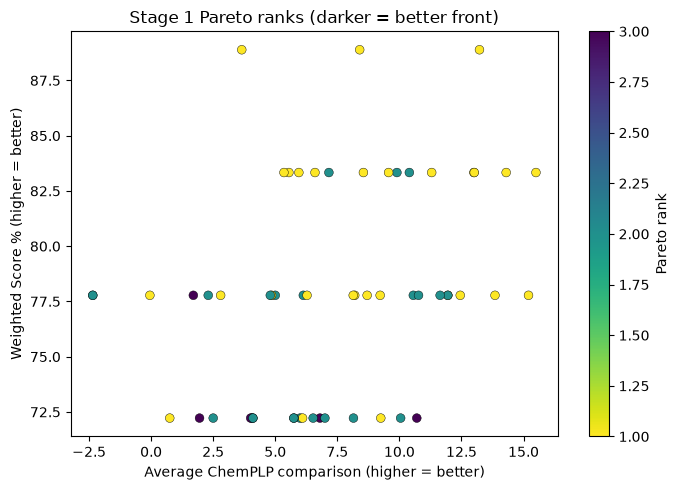

In [16]:
# 9. Visualisation
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    m["avg_chemplp_comparison"], m["weighted_score_pct"],
    c=m["pareto_rank"], cmap="viridis_r", s=40, edgecolor="k", linewidth=0.3
)
ax.set_xlabel("Average ChemPLP comparison (higher = better)")
ax.set_ylabel("Weighted Score % (higher = better)")
ax.set_title("Stage 1 Pareto ranks (darker = better front)")
plt.colorbar(sc, label="Pareto rank")
plt.tight_layout()
plt.show()


## Rationale to choose this approach

For this project, I needed a way to rank my docked candidate molecules that didn't rely on a single arbitrary "score" combining everything into one number. So, on my supervisors recommendation I resorted to Pareto Optimisation. The core idea behind Pareto optimisation comes from multi-objective decision theory which is what i intended to obtain i.e to come with a ranking list that is not biased with one parameter while disregarding other. 

In simple terms, one molecule "dominates" another if it beats it on every single metric I am comparing, and is strictly better on at least one.

Let me explain this using my own spreadsheet. Say I am comparing Molecule A and Molecule B. I am looking at their Average ChemPLP comparison, their Standard Deviation, and their Ligand Efficiency.

If Molecule A has a higher ChemPLP comparison than B, a lower Standard Deviation than B, and a higher Ligand Efficiency than B, then A wins on all three counts. There is no reason to pick B over A. B is worse in every way that matters. So B gets dropped from the top group, and A stays.

But this does not always happen. Sometimes Molecule A has a better ChemPLP comparison, but Molecule B has better Ligand Efficiency instead. In this case, neither one beats the other on everything. A is better in one way, B is better in another way. This is a genuine trade off.

Pareto optimisation does not try to decide which one is more important. It does not force me to say ChemPLP comparison matters more than Ligand Efficiency, or the other way round. It just keeps both molecules, because both of them are "efficient" in their own way. Neither can be improved on one metric without getting worse on the other.

The group of molecules that survive this process, meaning none of them can be beaten on every metric at once, is called the Pareto front. Every molecule on this front represents a different balance of strengths. Some are stronger binders. Some are more ligand efficient. Some are more consistent. None of them is a strictly worse copy of another molecule on the list.